<a href="https://colab.research.google.com/github/mdaugherity/Numerical2026/blob/main/roots/HW_2_Nonlinear_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2 - Nonlinear Systems

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar, root

# Problem 0
I have a quantum mechanics textbook that gives the solution to the system's energy as equation 2.156 here:
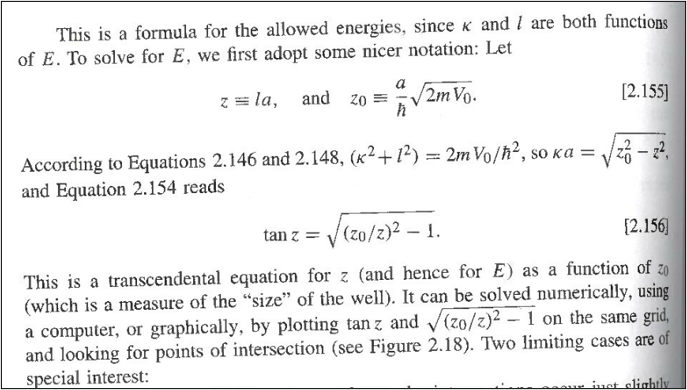

If that scan isn't legible, the equation we need is

$ \tan z = \sqrt{ (z_0/z)^2 - 1}  $  

Find all valid values of $z$ when $z_0 = 8$.   

*Hint: you can see the valid range of $z$ from the form of the equation...*

# PROBLEM 1 - More Quantum Madness

This code integrates the Schrodinger equation for a quantum object trapped in a potential well.  The energy E is unknown, but we observe that the wavefunction oscillates more rapidly as E is increased.  This code returns the value of the wavefunction on the far right side of the well.  This only legal values of E make this value zero.

Find E where PsiRight = 0.  Need EVERY root between E= 0 and 50.


In [2]:
def IntegrateTISE(x,V,E,psi0=0,psi1=1e-6):
  '''
  Uses eq (2.7) to calculate Psi by integrating the TISE
  INPUT: x and V arrays, energy E, psi0=psi[0]=psi at x[0], psi1=psi[1]
  RETURNS: psi array
  '''
# INITIALIZE
  psi = np.zeros_like(x)
  psi[0] = psi0
  psi[1] = psi1
  dx = x[1] - x[0]
  N = len(x)

  # MAIN LOOP
  for i in range(2,N):
    thisPsi = psi[i-1]
    lastPsi = psi[i-2]
    psi[i] = 2*thisPsi*(1 - dx**2 * (E-V[i])) - lastPsi # eq 2.7

  return psi

In [3]:
xMax = 1.5
dx = 0.001
x = np.arange(-xMax,xMax+dx,dx)
V = 50*np.heaviside(np.abs(x)-0.5,1) # Heaviside=0 for x<0, 1 for x>0

def PsiRight(E):  # return only the last psi for root finding
  psi = IntegrateTISE(x,V,E)
  return psi[-1]

In [4]:
PsiRight(0)

np.float64(145534.09548019548)

In [5]:
PsiRight(10)

np.float64(-3172.798295974798)

Notice that this version of PsiRight can't accept an array as input.  We can fix that pretty easily:

In [6]:
def PsiRightArray(E):  # runs PsiRight for each energy value in array E
  return [PsiRight(e) for e in E]

In [7]:
# check that this works
ES = np.arange(1,5)

print('Using PsiRight:')
for e in ES:
  print(PsiRight(e))

print('\nUsing PsiRightArray:')
print(PsiRightArray(ES))

Using PsiRight:
70993.99085435629
28398.90659683256
5610.253506038384
-5301.847309744133

Using PsiRightArray:
[np.float64(70993.99085435629), np.float64(28398.90659683256), np.float64(5610.253506038384), np.float64(-5301.847309744133)]


PsiRightArray will make plotting the function much easier

# Problem 2 - Nonlinear System
Here is a satellite tracking problem that is a non-linear system problem in flimsy disguise.

The equation for a orbiting satellite is

$ R = \frac{C}{1 + e \sin(\theta + \alpha)}$

where $R$ and $\theta$ are polar coordiates of the satellite, while $C$, $e$, and $\alpha$ are constants.  For three unknowns we have three recorded measurements of the satellite's position (for $R$ in km and $\theta$ in degrees)  $(R, \theta) = (6870, -30),  (6728, 0),  (6615, 30)$.

**PART A)** Find the values of the 3 unknowns

**PART B)** Make a polar coordiate plot of the orbit.